<a href="https://colab.research.google.com/github/rasikacs23172/mechine-learning-tae/blob/main/model_2_SVR_70_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
from io import StringIO

file_path = '/content/drive/MyDrive/student-mat (1).csv'

try:
    # Read the file content manually
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Extract header from the first line and split it
    header_line = lines[0].strip()
    column_names = header_line.split(';')

    # Process data lines: remove the outer double quotes that encapsulate the entire line
    processed_data_lines_content = []
    for line in lines[1:]:
        stripped_line = line.strip() # Remove trailing newline and any leading/trailing whitespace
        if stripped_line.startswith('"') and stripped_line.endswith('"'):
            # If the line is entirely wrapped in quotes, remove them
            processed_data_lines_content.append(stripped_line[1:-1])
        else:
            processed_data_lines_content.append(stripped_line)

    # Join the processed lines to form a single string that StringIO can read.
    data_string = "\n".join(processed_data_lines_content)

    # Read the processed data string using pandas, now it should parse semicolons correctly.
    # pandas will handle `""` (double quotes for escaped quotes) by default.
    df = pd.read_csv(StringIO(data_string), sep=';', header=None)
    df.columns = column_names

    # Clean up extra double quotes within string columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.replace('""', '', regex=False)
        df[col] = df[col].astype(str).str.strip()

    # Convert relevant columns to numeric types
    for col in ['G1', 'G2', 'G3', 'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']:
        df[col] = pd.to_numeric(df[col])

    print("Dataset loaded and cleaned successfully. Displaying the first 5 rows:")
    display(df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the 'student-mat.csv' file is uploaded to your Colab environment or is accessible at this path.")
    print("You can upload files using the file browser on the left sidebar in Colab.")
except Exception as e:
    print(f"An error occurred during file loading or processing: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded and cleaned successfully. Displaying the first 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [13]:
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

def prepare_data(df_input, test_size):
    """Splits data, applies one-hot encoding, and scales features."""
    df_copy = df_input.copy() # Work on a copy to avoid modifying original df
    categorical_cols = [
        'school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
        'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
        'nursery', 'higher', 'internet', 'romantic'
    ]
    df_encoded = pd.get_dummies(df_copy, columns=categorical_cols, drop_first=True)

    X = df_encoded.drop('G3', axis=1) # Target is 'G3'
    y = df_encoded['G3']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test, X, y # Return X, y for consistent visualization

def train_and_evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test):
    """Trains a model, makes predictions, and calculates evaluation metrics."""
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics = {
        'MAE': mae,
        'MSE': mse,
        'R2': r2
    }
    return metrics, y_pred

print("Data preparation and model training/evaluation functions defined.")

Data preparation and model training/evaluation functions defined.


In [14]:
# --- 80:20 Split ---
print("\n--- Processing 80:20 Split (test_size=0.2) ---")
X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2, X_0_2, y_0_2 = prepare_data(df, test_size=0.2)

svr_model_0_2 = SVR(kernel='rbf')
metrics_0_2, y_pred_0_2 = train_and_evaluate_model(svr_model_0_2, X_train_scaled_0_2, X_test_scaled_0_2, y_train_0_2, y_test_0_2)

print("SVR Model Evaluation (80:20 Split):")
metrics_df_0_2 = pd.DataFrame(metrics_0_2.items(), columns=['Metric', 'Value'])
metrics_df_0_2.rename(columns={'Value': '80:20 Split'}, inplace=True)
display(metrics_df_0_2.round(4))


--- Processing 80:20 Split (test_size=0.2) ---
SVR Model Evaluation (80:20 Split):


,Metric,80:20 Split
0,MAE,1.8367
1,MSE,7.4312
2,R2,0.6376


In [15]:
# --- 70:30 Split ---
print("\n--- Processing 70:30 Split (test_size=0.3) ---")
X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3, X_0_3, y_0_3 = prepare_data(df, test_size=0.3)

svr_model_0_3 = SVR(kernel='rbf')
metrics_0_3, y_pred_0_3 = train_and_evaluate_model(svr_model_0_3, X_train_scaled_0_3, X_test_scaled_0_3, y_train_0_3, y_test_0_3)

print("SVR Model Evaluation (70:30 Split):")
metrics_df_0_3 = pd.DataFrame(metrics_0_3.items(), columns=['Metric', 'Value'])
metrics_df_0_3.rename(columns={'Value': '70:30 Split'}, inplace=True)
display(metrics_df_0_3.round(4))


--- Processing 70:30 Split (test_size=0.3) ---
SVR Model Evaluation (70:30 Split):


,Metric,70:30 Split
0,MAE,1.9972
1,MSE,9.2180
2,R2,0.5807


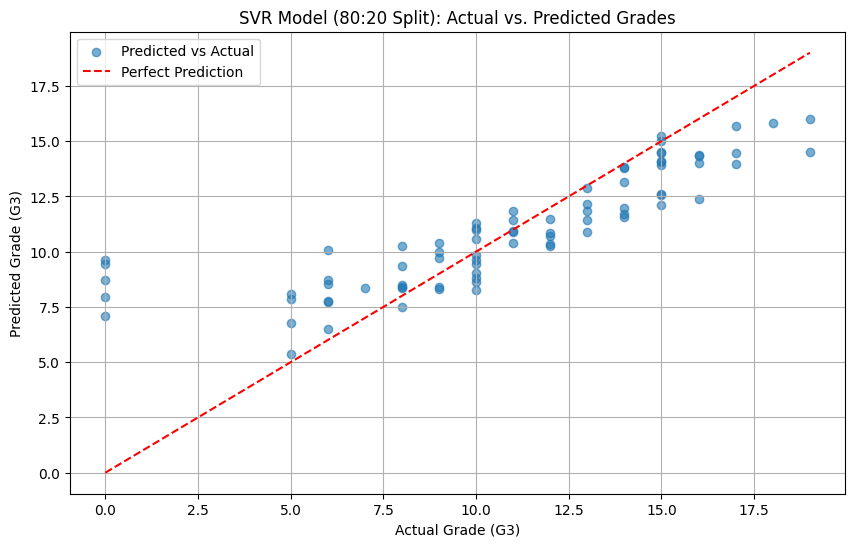

Prediction visualization completed for the 80:20 split.


In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test_0_2, y_pred_0_2, alpha=0.6, label='Predicted vs Actual')

# Add a line for perfect predictions
min_val = min(y_test_0_2.min(), y_pred_0_2.min())
max_val = max(y_test_0_2.max(), y_pred_0_2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade (G3)')
plt.title('SVR Model (80:20 Split): Actual vs. Predicted Grades')
plt.legend()
plt.grid(True)
plt.show()

print("Prediction visualization completed for the 80:20 split.")